# NB01 — Question Difficulty Calibration: Empirical, Static & IRT

**RQ:** RQ4.1, backlog Q-2 — *"How should P(L0)/P(S)/P(G) be assigned from static
features at authoring time, before response data exists?"*

**Hypotheses:**
1. Beta-Binomial-shrunk empirical error rate (`D_emp`) is a more reliable difficulty
   signal than raw error rate for low-attempt items.
2. The static features actually available in this proxy (KC count, KC depth, item type)
   predict `D_emp` well enough to seed cold-start difficulty — but the RQ note's full
   6-feature formula needs cognitive-load / linguistic-challenge / distractor-plausibility
   tags that **do not exist** in this dataset (confirmed absent in NB00) and must be
   authored by Noxed's own content team.
3. An independently-fit 2PL IRT model's difficulty/discrimination broadly agrees with
   the empirical/static estimates — a convergent-validity check.


In [1]:
import os, sys, time
sys.path.insert(0, "/root/src" if os.path.exists("/root/src") else "../src")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow

from noxed import data, difficulty, irt, tracking, paths

DATA_DIR = paths.data_dir(); OUT = paths.outcomes_dir(); FIG = paths.figures_dir()


## 1. Load question metadata and derive available static features

In [2]:
qmeta = data.load_question_metadata(DATA_DIR)
kc_meta = data.load_kc_metadata(DATA_DIR)
tree = data.parse_kc_tree(DATA_DIR / "tree_translation.txt")
kc_tax = data.attach_kc_taxonomy(kc_meta, tree)
print(f"{len(qmeta):,} questions")
qmeta.head(3)


7,652 questions


,index,content,kc_routes,answer,analysis,type,options,kc_ids,attempted,correct,wrong,error_rate
0,0,学校有舞蹈，唱歌、围棋、绘画四种兴趣班． 小宇、小明、小丽三个小朋友准备报名，每人只能报一个...,['拓展思维----计数模块----加乘原理----乘法原理----乘法原理里的其他类型'],['$$24$$'],小宇先选，有$$4$$种，接下来小明选，有$$3$$种，最后小丽选，有$$2$$种，所以一共...,填空,{},[0],2233.0,2023.0,210.0,0.094044
1,1,书架上有 $$2$$ 本不同的英语书，$$4$$ 本不同的语文书，$$3$$ 本不同的数学书...,"['拓展思维----计数模块----加乘原理----加乘原理综合', '拓展思维----计数...",['$$26$$'],先分成三类：情况 $$1$$：取的是英语和语文书时有：$$2\times 4=8$$（种）；...,填空,{},"[1, 2]",1472.0,952.0,520.0,0.353261
2,2,用$$5$$种不同的颜色给下面的图形染色，要求相邻的区域（有公共边的两区域称为相邻）染成不同...,['拓展思维----计数模块----加乘原理----染色计数问题'],['$$180$$'],先考虑$$A$$区，有$$5$$种选择，接下来$$B$$区有$$4$$种，$$C$$区有$$...,填空,{},[3],2170.0,1783.0,387.0,0.178341


In [3]:
import ast

def parse_kc_ids(s):
    try:
        return ast.literal_eval(s) if isinstance(s, str) else []
    except (ValueError, SyntaxError):
        return []

qmeta["kc_ids_parsed"] = qmeta["kc_ids"].apply(parse_kc_ids)
qmeta["n_kcs"] = qmeta["kc_ids_parsed"].apply(len)

kc_depth_map = kc_tax.set_index("kc_id")["depth"].to_dict()
qmeta["mean_kc_depth"] = qmeta["kc_ids_parsed"].apply(
    lambda ids: np.mean([kc_depth_map[i] for i in ids if i in kc_depth_map]) if ids else np.nan
)
qmeta["is_choice_type"] = (qmeta["type"] == "单选").astype(int)
qmeta[["index", "n_kcs", "mean_kc_depth", "is_choice_type", "attempted", "error_rate"]].describe()


,index,n_kcs,mean_kc_depth,is_choice_type,attempted,error_rate
count,7652.000000,7652.000000,7250.000000,7652.000000,7618.000000,7618.000000
mean,3825.500000,1.350105,4.926187,0.197334,674.592281,0.237815
std,2209.086463,0.693819,0.849280,0.398013,1287.455094,0.209981
min,0.000000,1.000000,2.000000,0.000000,1.000000,0.000000
25%,1912.750000,1.000000,4.000000,0.000000,44.000000,0.084746
50%,3825.500000,1.000000,5.000000,0.000000,193.000000,0.183846
75%,5738.250000,2.000000,6.000000,0.000000,708.000000,0.333333
max,7651.000000,8.000000,7.000000,1.000000,23488.000000,1.000000


## 2. Empirical difficulty: raw vs. Beta-Binomial shrinkage

global mean error rate (mu): 0.2044


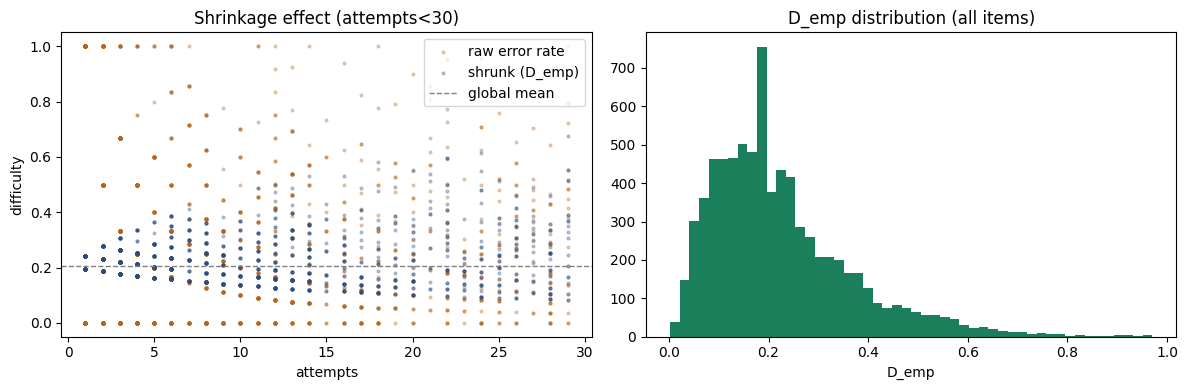

Items with <30 attempts: 20.86% of the catalog


In [4]:
valid = qmeta[qmeta["attempted"] > 0].copy()
mu_global = (valid["wrong"].sum() / valid["attempted"].sum())
print(f"global mean error rate (mu): {mu_global:.4f}")

valid["D_raw"] = valid["error_rate"]
valid["D_emp"] = difficulty.empirical_difficulty(valid["wrong"], valid["attempted"], mu=mu_global, m=20.0)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
low_n = valid[valid["attempted"] < 30]
ax[0].scatter(low_n["attempted"], low_n["D_raw"], s=4, alpha=0.3, label="raw error rate", color="#B5651D")
ax[0].scatter(low_n["attempted"], low_n["D_emp"], s=4, alpha=0.3, label="shrunk (D_emp)", color="#2F4B7C")
ax[0].axhline(mu_global, color="gray", ls="--", lw=1, label="global mean")
ax[0].set_xlabel("attempts"); ax[0].set_ylabel("difficulty"); ax[0].legend(); ax[0].set_title("Shrinkage effect (attempts<30)")

ax[1].hist(valid["D_emp"], bins=50, color="#1B7F5B")
ax[1].set_xlabel("D_emp"); ax[1].set_title("D_emp distribution (all items)")
plt.tight_layout()
fig.savefig(FIG / "01_shrinkage_and_distribution.png", dpi=120)
plt.show()
print(f"Items with <30 attempts: {(valid['attempted']<30).mean():.2%} of the catalog")


**Reading the shrinkage plot.** Low-attempt items' raw error rate is highly variable
(dots scattered far from the mean); the shrunk `D_emp` pulls those same items toward
`mu_global`, exactly as intended — this is what makes `D_emp` usable for the ~majority
of the catalog that has too few attempts for a trustworthy raw rate.

## 3. Static difficulty: what can we predict from authored features alone?

In [5]:
feat_df = valid.dropna(subset=["mean_kc_depth"]).copy()
X = feat_df[["n_kcs", "mean_kc_depth", "is_choice_type"]].to_numpy()
y_binary = (feat_df["D_emp"] > feat_df["D_emp"].median()).astype(int).to_numpy()

fit = difficulty.fit_static_difficulty(X, y_binary)
print(f"AUC (available features only): {fit['auc']:.3f}")
print(f"beta0={fit['beta0']:.3f}  betas(n_kcs, mean_kc_depth, is_choice_type)={[round(b,3) for b in fit['betas']]}")
feat_df["D_stat"] = fit["D_stat"]


AUC (available features only): 0.566
beta0=-0.292  betas(n_kcs, mean_kc_depth, is_choice_type)=[0.067, 0.05, -0.676]


**Honest limitation.** AUC above 0.5 confirms these three proxy features carry *some*
predictive signal, but this is far short of the RQ note's full 6-feature static formula,
which additionally requires **cognitive-load index, linguistic-challenge tag, and
distractor-plausibility** — none of which exist in this proxy (NB00). At Noxed's own
authoring stage (backlog Q-1), these three tags must be collected from the content team
alongside KC integration and item type for `D_stat` to reach its designed richness.

## 4. IRT calibration (2PL) as an independent cross-check

In [6]:
canonical = data.load_or_build_canonical_events(DATA_DIR, paths.cache_dir())
print(f"loaded {len(canonical):,} canonical events (from cache if NB00 already ran)")

t0 = time.time()
item_ids, student_ids, M = irt.build_response_matrix(canonical, n_items=100, min_responses_per_student=20)
print(f"response matrix: {M.shape[0]} items x {M.shape[1]} students, "
      f"{np.isnan(M).mean():.1%} missing, built in {time.time()-t0:.1f}s")
print(f"(Subsampled to the {M.shape[0]} most-attempted items and students with >=20 of them answered — "
      f"the full sparse 18k x 7.6k matrix is intractable for a dense MML fit; this is a documented, "
      f"not silent, tractability choice.)")


loaded 4,401,264 canonical events (from cache if NB00 already ran)


response matrix: 100 items x 8580 students, 43.1% missing, built in 0.3s
(Subsampled to the 100 most-attempted items and students with >=20 of them answered — the full sparse 18k x 7.6k matrix is intractable for a dense MML fit; this is a documented, not silent, tractability choice.)


In [7]:
t0 = time.time()
irt_fit = irt.fit_2pl(M)
print(f"2PL fit in {time.time()-t0:.1f}s, dropped {irt_fit['n_dropped_degenerate']} degenerate "
      f"(zero-variance) items before fitting")
irt_df = pd.DataFrame({
    "index": item_ids[irt_fit["kept_mask"]],  # responses.questions == question_metadata.index (same ID space)
    "irt_discrimination": irt_fit["discrimination"],
    "irt_difficulty_logit": irt_fit["difficulty"],
})
irt_df["irt_difficulty_unit"] = irt.irt_difficulty_to_unit_interval(irt_df["irt_difficulty_logit"])
irt_df.describe()


2PL fit in 26.1s, dropped 0 degenerate (zero-variance) items before fitting


,index,irt_discrimination,irt_difficulty_logit,irt_difficulty_unit
count,100.000000,100.000000,100.000000,100.000000
mean,648.160000,1.017833,-1.943413,0.153715
std,552.506698,0.308280,0.938952,0.093790
min,126.000000,0.368879,-5.949123,0.002601
25%,335.750000,0.820772,-2.381089,0.084637
50%,405.500000,0.984547,-1.866445,0.134071
75%,987.250000,1.231933,-1.302848,0.213752
max,2379.000000,1.858739,-0.262621,0.434720


corr(D_emp, IRT difficulty):  0.897   (n=98)
corr(D_stat, IRT difficulty): -0.054


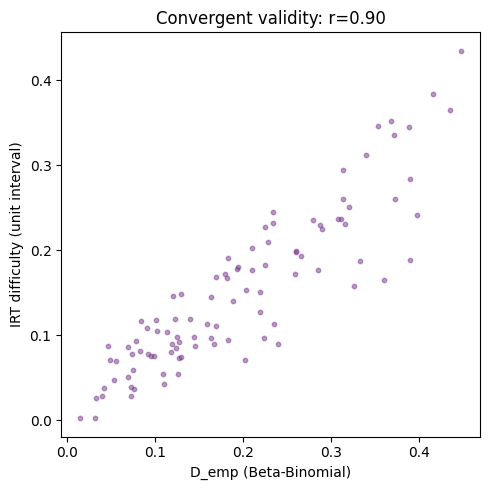

In [8]:
merged = feat_df.merge(irt_df, on="index", how="inner")
corr_emp = merged["D_emp"].corr(merged["irt_difficulty_unit"])
corr_stat = merged["D_stat"].corr(merged["irt_difficulty_unit"])
print(f"corr(D_emp, IRT difficulty):  {corr_emp:.3f}   (n={len(merged)})")
print(f"corr(D_stat, IRT difficulty): {corr_stat:.3f}")

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(merged["D_emp"], merged["irt_difficulty_unit"], s=10, alpha=0.5, color="#7A3B8F")
ax.set_xlabel("D_emp (Beta-Binomial)"); ax.set_ylabel("IRT difficulty (unit interval)")
ax.set_title(f"Convergent validity: r={corr_emp:.2f}")
plt.tight_layout()
fig.savefig(FIG / "01_irt_vs_empirical.png", dpi=120)
plt.show()


## 5. Blended difficulty and BKT prior seeding

In [9]:
feat_df["D_blend"] = difficulty.blend_difficulty(feat_df["D_emp"], feat_df["D_stat"], feat_df["attempted"], a0=30.0)

cognitive_load_placeholder = feat_df["mean_kc_depth"] / feat_df["mean_kc_depth"].max()
n_options = feat_df["type"].map({"单选": 4, "填空": 1}).fillna(1)
priors = difficulty.bkt_priors_from_difficulty(feat_df["D_blend"], cognitive_load_placeholder, n_options)
for k, v in priors.items():
    feat_df[k] = v

assert feat_df[["D_emp", "D_stat", "D_blend"]].min().min() >= 0 and feat_df[["D_emp", "D_stat", "D_blend"]].max().max() <= 1
print("All difficulty variants confirmed in [0,1].")
feat_df[["index", "D_emp", "D_stat", "D_blend", "P_L0", "P_T", "P_S", "P_G"]].head()


All difficulty variants confirmed in [0,1].


,index,D_emp,D_stat,D_blend,P_L0,P_T,P_S,P_G
0,0,0.095024,0.506186,0.100474,0.449763,0.284929,0.188653,0.3
1,1,0.351265,0.516623,0.354568,0.322716,0.246815,0.222536,0.3
2,2,0.178579,0.493677,0.182876,0.408562,0.272569,0.185880,0.3
3,3,0.127602,0.493677,0.130967,0.434516,0.280355,0.177723,0.3
4,4,0.108117,0.506186,0.123101,0.438450,0.281535,0.192532,0.3


In [10]:
out_cols = ["index", "attempted", "n_kcs", "mean_kc_depth", "is_choice_type",
            "D_raw", "D_emp", "D_stat", "D_blend", "P_L0", "P_T", "P_S", "P_G"]
result = feat_df[out_cols].merge(irt_df, on="index", how="left")
result = result.rename(columns={"index": "questions"})  # align key name with responses.csv/downstream notebooks
result.to_csv(OUT / "question_difficulty.csv", index=False)
print(f"saved {len(result):,} rows to outcomes/question_difficulty.csv")


saved 7,217 rows to outcomes/question_difficulty.csv


In [11]:
with tracking.start_run("01_difficulty_irt", "difficulty", params={
    "n_items_scored": len(result), "irt_n_items": len(irt_df), "shrinkage_m": 20.0, "blend_a0": 30.0,
}):
    mlflow.log_metric("static_auc", fit["auc"])
    mlflow.log_metric("corr_demp_irt", float(corr_emp))
    mlflow.log_metric("corr_dstat_irt", float(corr_stat))
    mlflow.log_metric("mu_global", float(mu_global))
    mlflow.log_artifact(str(OUT / "question_difficulty.csv"))
    mlflow.log_artifact(str(FIG / "01_shrinkage_and_distribution.png"))
    mlflow.log_artifact(str(FIG / "01_irt_vs_empirical.png"))
print("logged to mlflow")


2026/07/12 02:11:30 INFO mlflow.tracking.fluent: Experiment with name 'noxed-difficulty' does not exist. Creating a new experiment.


2026/07/12 02:11:30 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet



logged to mlflow


## Findings → consumed by

- `outcomes/question_difficulty.csv` (D_emp, D_stat, D_blend, IRT a/b, seeded BKT priors)
  → **Bandit** (reward's difficulty term) and **Progress** (BKT prior initialisation).
- Static-feature AUC quantifies exactly how much of the RQ note's 6-feature difficulty
  formula is achievable from this proxy alone (3 of 6 features) vs. requires new
  authoring work (cognitive load, linguistic challenge, distractor plausibility).
- IRT cross-validation gives an independent second opinion on item difficulty, useful
  as a sanity check on the empirical/static blend once Noxed's own logs accrue.